# Quantum Mechanics/Molecular Mechanics (QM/MM) Dynamics Analysis Example Workflow

This notebook demonstrates the primary analysis functions included in QTRAP. The example paths, masks, thresholds, and residue selections are intended as templates and should be modified for new systems before running.

The workflow is organized around three analysis tasks:

1. Coordinate tracking and trajectory outcome classification
2. Per-residue root mean square deviation (RMSD) analysis
3. Partial decomposition analysis (PDA) of residue-ligand interaction energies

Trajectory functions accept Amber NetCDF (`.nc`) trajectories or .xyz trajectories with matching `.parm7` or `.prmtop` topology files. Coordinate thresholds are specified as strings such as `"greater than 2.5"` or `"less than 1.7"`.

The functions used for coordinate tracking and trajectory outcome classification may also be used effectively for traditional quasiclassical dynamics trajectory analysis with no MM-treated receptor.

## 1. Coordinate Tracking: One-Constraint Outcome Classification

This function is intended for cases where one diagnostic coordinate is sufficient to classify each trajectory outcome. This is useful for systems where multiple products can form and each product can be recognized from one distance, angle, or dihedral.

Mask length determines the measured coordinate:

- 2 atoms = distance
- 3 atoms = angle
- 4 atoms = dihedral

This function generates coordinate vs. time plots for each tracked coordinate and reports the file paths corresponding to trajectories that arrived at a product or reactant/intermediate, as well as the name of the product or reactant/intermediate formed.

QM/MM dynamics trajectories run in one arbitrary direction along the ligand reaction coordinate (positive or negative) are analyzed below.

In [ ]:
import sys

sys.path.append("/Path/to/QTRAP")

[('/Users/riversamet/Downloads/cope-anton/frame_16000-cen-oniom-traj-n1.nc',
  'Backward Int.'),
 ('/Users/riversamet/Downloads/cope-anton/frame_16000-cen-oniom-traj-n10.nc',
  'Backward Int.'),
 ('/Users/riversamet/Downloads/cope-anton/frame_16000-cen-oniom-traj-n2.nc',
  'Backward Int.'),
 ('/Users/riversamet/Downloads/cope-anton/frame_16000-cen-oniom-traj-n3.nc',
  'Backward Int.'),
 ('/Users/riversamet/Downloads/cope-anton/frame_16000-cen-oniom-traj-n4.nc',
  'Backward Int.')]

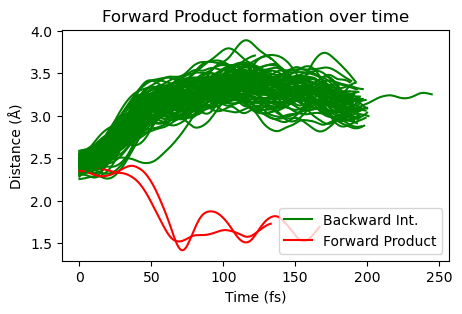

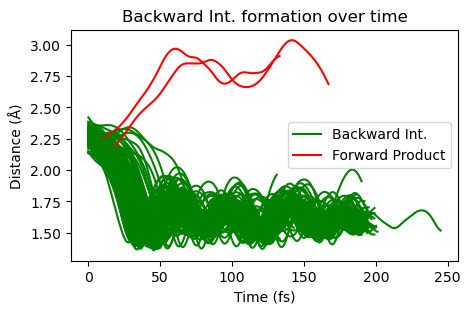

In [ ]:
import qtrap_analysis as qt

traj_dir = '/Path/to/traj/dir'

masks_list = [
    ":1@C19 :1@C27",
    ":1@C22 :1@C24",
]

trans_names_list = [
    'Forward Product', 
    'Backward Int.',
]

thresholds = [
    'less than 1.6', 
    'less than 1.6',
]

colors_list = [
    "red",
    "green",
]

product_trajectories, product_labels = qt.plot_coordinate_outcomes_one_constraint(
    traj_dir=traj_dir,
    masks_list=masks_list,
    trans_names_list=trans_names_list,
    thresholds=thresholds,
    colors_list=colors_list,
    trajfiletype="xyz",
)

list(zip(product_trajectories[:5], product_labels[:5]))

In this simple case, all trajectories are assigned to either the forward product or backward intermediate based on the diagnostic distances. More complex QM/MM dynamics simulations may require multiple coordinates to classify a trajectory outcome reliably. 

Transition states can also take longer to arrive at reactants/intermediates and products -- these kinds of simulations can often be problematic, so one should not expect such clean results consistently.


## 2. Coordinate Tracking: Multi-Constraint Outcome Classification

The previous example classified trajectories using one coordinate at a time. This version requires all forward constraints to be satisfied in the same frame before the forward product is assigned. If the forward product is not assigned, the same logic is applied to the reverse/reactant constraints. Trajectories that satisfy neither set of constraints are reported as remaining in the transition-state region.

This approach is appropriate when product formation depends on multiple coordinate changes occurring together. This function generates coordinate vs. time plots for each tracked coordinate and reports the file paths corresponding to trajectories arriving at a product or reactant/intermediate, as well as the name of the product or reactant/intermediate formed.

QM/MM dynamics trajectories run in one arbitrary direction along the ligand reaction coordinate (positive or negative) are analyzed below.

[('/Users/riversamet/Downloads/ez-anton/frame_15000-cen-oniom-mix-rigid-traj-n1.nc',
  'Forward Product'),
 ('/Users/riversamet/Downloads/ez-anton/frame_15000-cen-oniom-mix-rigid-traj-n10.nc',
  'Forward Product'),
 ('/Users/riversamet/Downloads/ez-anton/frame_15000-cen-oniom-mix-rigid-traj-n3.nc',
  'Forward Product'),
 ('/Users/riversamet/Downloads/ez-anton/frame_15000-cen-oniom-mix-rigid-traj-n4.nc',
  'Forward Product'),
 ('/Users/riversamet/Downloads/ez-anton/frame_15000-cen-oniom-mix-rigid-traj-n6.nc',
  'Forward Product')]

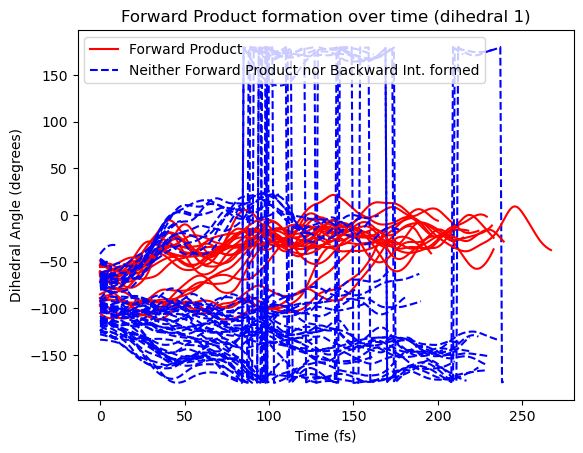

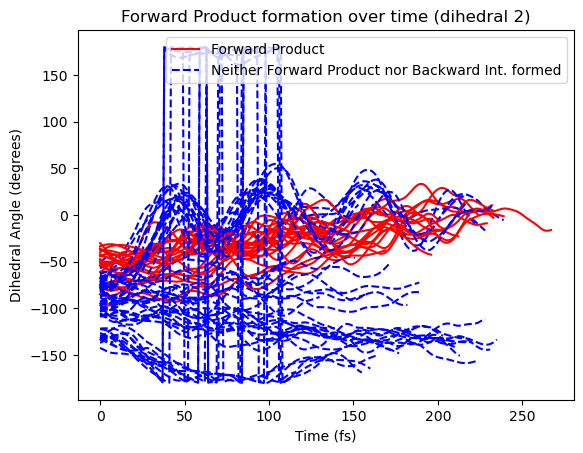

In [ ]:
traj_dir = '/Path/to/traj/dir'

masks_list_forwards = [
    ":1@C15 :1@C16 :1@C18 :1@C19",
    ":1@C18 :1@C19 :1@C21 :1@C22",
]

masks_list_backwards = [
    ":1@C15 :1@C16 :1@C18 :1@C19",
    ":1@C18 :1@C19 :1@C21 :1@C22",
]

thresholds_forwards = [
    "less than 30",
    "less than 30",
]

thresholds_backwards = [
    "greater than 150",
    "greater than 150",
]

product_trajectories, product_labels = qt.plot_coordinate_outcomes_multi_constraint(
    traj_dir=traj_dir,
    masks_list_forwards=masks_list_forwards,
    masks_list_backwards=masks_list_backwards,
    trans_name_forwards="Forward Product",
    trans_name_backwards="Backward Int.",
    thresholds_forwards=thresholds_forwards,
    thresholds_backwards=thresholds_backwards,
    color_forwards="red",
    color_backwards="green",
    trajfiletype="xyz",
    abs_list_forwards=[True, True],
    add_text_forwards=["dihedral 1", "dihedral 2"],
)

list(zip(product_trajectories[:5], product_labels[:5]))

For some dynamics simulations, many trajectories may remain near the transition-state region rather than quickly forming either product. The multi-constraint function is useful for identifying these cases without overassigning trajectories based on only one coordinate.

## 3. Per-Residue RMSD Frequency

This QM/MM dynamics analysis method identifies receptor residues that repeatedly deviate beyond a chosen RMSD threshold across trajectory endpoints. This can help to show which residues must undergo conformational shifts for ligand reactivity, highlighting the importance of these residues in catalysis.

The function aligns each trajectory using `overall_mask`, builds a reference structure from the first `reference_frames` frames, and measures per-residue RMSD over the final `reference_frames` frames. Residues whose average RMSD exceeds a user-defined threshold are counted across trajectories.

The function generates a bar plot displaying how often each residue exceeds the RMSD threshold. It also prints residues whose counts exceed `print_threshold`, as these are the most likely residues to undergo conformational changes.

QM/MM dynamics trajectories run in one arbitrary direction along the ligand reaction coordinate (positive or negative) are analyzed below.

Residue 47 shifted by at least 1 Å 21 times.
Residue 57 shifted by at least 1 Å 24 times.


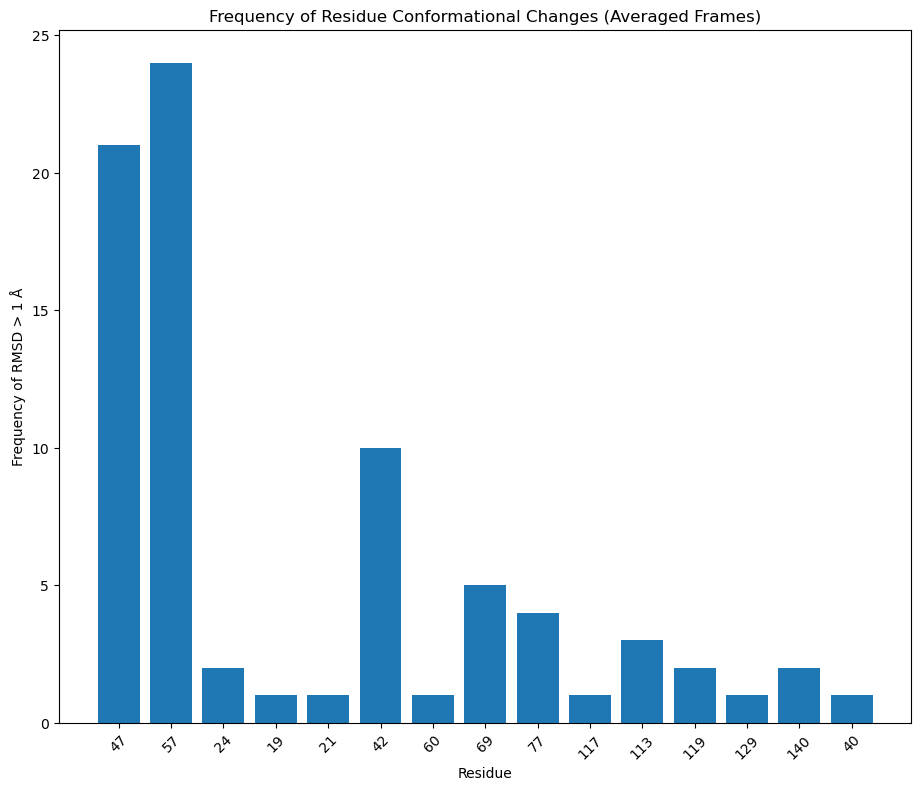

In [ ]:
traj_dir = '/Path/to/traj/dir'

qt.per_residue_RMSD(
    traj_dir=traj_dir,
    overall_mask='!(:WAT|:Na+)&!@H=',
    res_mask="&!@H=",
    threshold=1,
    trajfiletype="xyz",
    print_threshold=10,
    min_frames=50,
    reference_frames=20,
)

Residues that have frequencies of conformational changes approximately equal to the number of trajectories that went to reactant/intermediate or product are of high interest for further investigation, as their shifts correlate quite well with motion along the ligand reaction coordinate.

## 4. PDA: Absolute Interaction Energy-Based Filtering

This function compares residue-ligand interaction energies from Amber `MMPBSA.py` PDA outputs. This analysis can highlight residues that are especially important for stabilizing ligand binding, as well as the residues that have the largest changes in ligand stabilization as the ligand proceeds along a reaction coordinate.

Typical use cases include comparing forward and reverse QM/MM dynamics trajectories and/or molecular dynamics (MD) trajectories.

The function generates a bar chart grouped by residue ID showing residue-ligand interaction energies for multiple processes. In the example below, only residues with interaction energies below the selected threshold are plotted for the specified process. The next PDA example instead filters residues based on the interaction energy difference between two processes for each residue.

QM/MM dynamics trajectories run in both directions along the ligand reaction coordinate are compared and analyzed below.

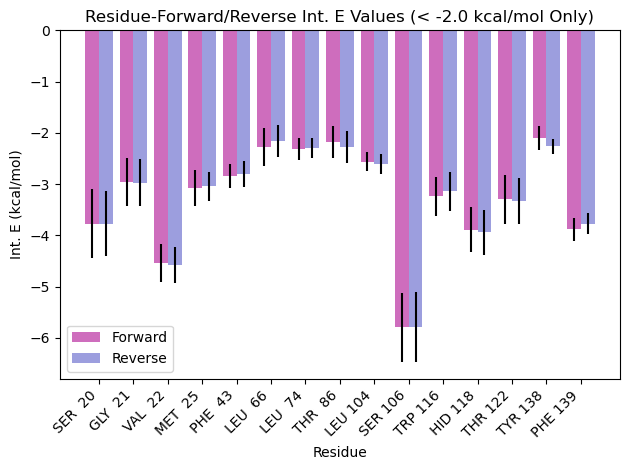

In [ ]:
traj_dirs = [
    "/Path/to/forward/dir",
    "/Path/to/reverse/dir",
]

processes = [
    "Forward",
    "Reverse",
]

qt.partial_decomposition_analysis_separate(
    traj_dirs=traj_dirs,
    traj_analysis_time=75,
    processes=processes,
    threshold=-2.0,
    threshold_process="Forward",
)

Energies are grouped by residue ID so that residue-specific interaction energies can be compared directly between processes. Standard deviations are included to show variability across trajectories.

If many residues pass the threshold, the threshold can be adjusted to focus on the strongest stabilizing interactions.

## 5. PDA: Difference-Based Filtering

Instead of filtering residues by absolute interaction strength, residues can be selected based on how different their interaction energies are between two processes.

Here, MD simulations for two different structures are used to generate plots (as opposed to QM/MM dynamics simulations) because this data provides a clear example of process-dependent interaction energy differences. This also demonstrates the ability of this function to work on different types of dynamics simulations.

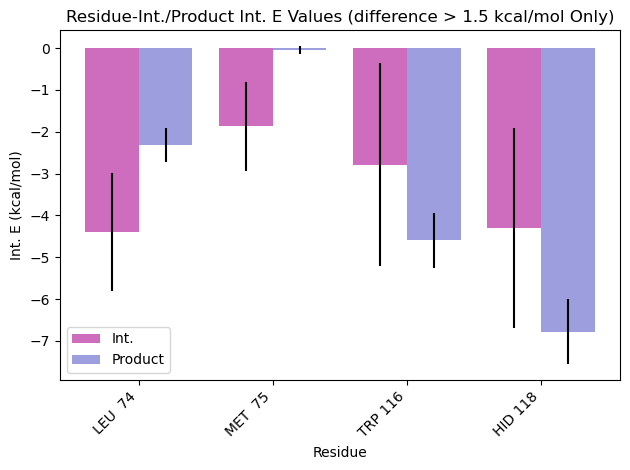

In [ ]:
traj_dirs = [
    "/Path/to/structure/dir",
    "/Path/to/other_structure/dir",
]

processes = [
    "Int.",
    "Product"
]

qt.partial_decomposition_analysis_separate(
    traj_dirs=traj_dirs,
    traj_analysis_time=75,
    processes=processes,
    difference=1.5,
    difference_processes=["Int.", "Product"],
    example_dir_alt='/Path/to/example/dir/alt',
    example_dir_opt='Relative/path/to/example/dir/opt',
)

Standard deviations help distinguish meaningful process-dependent interaction changes from regions with high flexibility or noisy interaction energies.



## 6. PDA: Summed Interaction Energies

This function compares summed residue-ligand interaction energies across processes. Each process is plotted as a stacked bar, and each residue's contribution is shown with a different color.

The main difference from the previous PDA function is that this plot emphasizes the total stabilizing interaction energy for each process, while the previous function compares individual residue interaction energies between processes.

MD simulations of two different structures are used to generate plots.

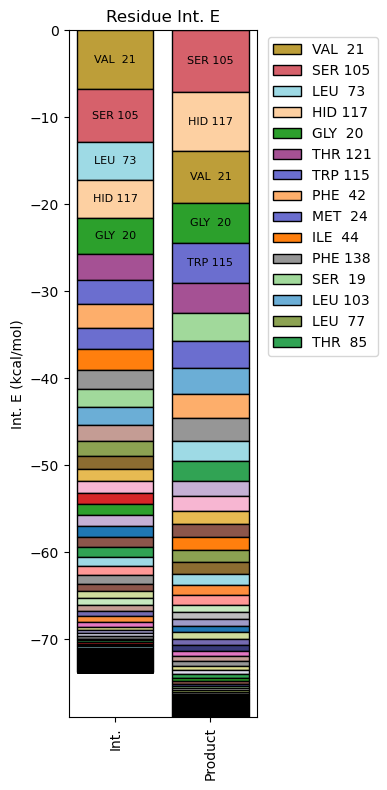

In [ ]:
pda_files = [
    "/Path/to/structure/dir/FINAL_DECOMP_MMPBSA-c.dat",
    "/Path/to/other_structure/dir/FINAL_DECOMP_MMPBSA-c.dat"
]

qt.partial_decomposition_analysis_combined(
    pda_files=pda_files,
    processes=processes,
    threshold=0
)

The residues with the largest residue-ligand interaction energy contributions are labeled on the plot. In this example, `threshold=0` is used to display all stabilizing residue-ligand interactions, which gives a broad comparison of interaction energy contributions between the two processes.

## 7. Notes for Adapting This Notebook

Before running this notebook on a new system:

- Confirm that QM/MM dynamics trajectory filenames match the expected `*-oniom*.nc` or `*-oniom*.xyz` naming pattern.
- Confirm that each trajectory has a matching `.parm7` or `.prmtop` topology file with the same base name as the trajectory file before the `-oniom*.*` suffix.
- Use pytraj masks that match your topology and residue numbering.
- For PDA analysis, run the preprocessing/MMPBSA workflow first so that shortened `FINAL_DECOMP_MMPBSA-c*.dat` files are available.
- Treat the example masks and thresholds above as placeholders, not chemically general defaults.
- Check the README for more detailed documentation on all functions.

